In [1]:
# =========================================================
# COMPLETE IMPROVED VIDEO VIOLENCE DETECTION PIPELINE
# CNN (InceptionV3) + BiLSTM
# =========================================================

%matplotlib inline

import os
import cv2
import numpy as np
from random import shuffle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LSTM, Bidirectional
)
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.optimizers import Adam

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_DIR = "data"
IMG_SIZE = 299
FRAMES_PER_VIDEO = 20
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 1e-4

# -----------------------------
# LOAD VIDEO NAMES & LABELS
# -----------------------------
def load_video_names_and_labels(data_dir):
    names, labels = [], []

    if not os.path.exists(data_dir):
        raise ValueError(f"DATA_DIR does not exist: {data_dir}")

    for file in os.listdir(data_dir):
        if not file.lower().endswith(".mp4"):
            continue

        file_lower = file.lower()

        if file_lower.startswith("v_"):
            names.append(file)
            labels.append([1, 0])
        elif file_lower.startswith("nv_"):
            names.append(file)
            labels.append([0, 1])

    if len(names) == 0:
        raise ValueError(
            "No valid videos found.\n"
            "Expected filenames like:\n"
            "  v_*.mp4   (violence)\n"
            "  nv_*.mp4  (non-violence)"
        )

    combined = list(zip(names, labels))
    shuffle(combined)

    names, labels = zip(*combined)
    return list(names), np.array(labels)


# -----------------------------
# FRAME EXTRACTION
# -----------------------------
def extract_frames(video_path, n_frames=FRAMES_PER_VIDEO):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < n_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)

    cap.release()

    if len(frames) < n_frames:
        return None

    frames = np.array(frames, dtype=np.float32)
    frames = preprocess_input(frames)
    return frames

# -----------------------------
# FEATURE EXTRACTOR (CNN)
# -----------------------------
cnn = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
cnn.trainable = False

FEATURE_DIM = cnn.output_shape[-1]

# -----------------------------
# BUILD DATASET
# -----------------------------
def build_dataset(names, labels):
    X, y = [], []

    for name, label in zip(names, labels):
        frames = extract_frames(os.path.join(DATA_DIR, name))
        if frames is None:
            continue

        features = cnn.predict(frames, verbose=0)
        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)

# -----------------------------
# LOAD DATA
# -----------------------------
names, labels = load_video_names_and_labels(DATA_DIR)

split = int(0.8 * len(names))
train_names, test_names = names[:split], names[split:]
train_labels, test_labels = labels[:split], labels[split:]

X_train, y_train = build_dataset(train_names, train_labels)
X_test, y_test = build_dataset(test_names, test_labels)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# -----------------------------
# MODEL (BiLSTM)
# -----------------------------
model = Sequential([
    Bidirectional(
        LSTM(256),
        input_shape=(FRAMES_PER_VIDEO, FEATURE_DIM)
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# TRAINING
# -----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=5,
        factor=0.3
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2
)

# -----------------------------
# EVALUATION
# -----------------------------
results = model.evaluate(X_test, y_test, verbose=0)

print("\nTest results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


Train: (1560, 20, 2048) (1560, 2)
Test : (391, 20, 2048) (391, 2)


C:\Users\gabri\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 512)            │     4,720,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,855,554 (18.52 MB)

 Trainable params: 4,854,018 (18.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/60
39/39 - 9s - 218ms/step - accuracy: 0.7107 - loss: 0.7340 - val_accuracy: 0.7468 - val_loss: 0.4952 - learning_rate: 1.0000e-04
Epoch 2/60
39/39 - 5s - 135ms/step - accuracy: 0.8446 - loss: 0.3757 - val_accuracy: 0.7756 - val_loss: 0.4445 - learning_rate: 1.0000e-04
Epoch 3/60
39/39 - 6s - 144ms/step - accuracy: 0.8814 - loss: 0.3128 - val_accuracy: 0.9231 - val_loss: 0.2840 - learning_rate: 1.0000e-04
Epoch 4/60
39/39 - 10s - 253ms/step - accuracy: 0.8990 - loss: 0.2466 - val_accuracy: 0.9295 - val_loss: 0.2415 - learning_rate: 1.0000e-04
Epoch 5/60
39/39 - 5s - 137ms/step - accuracy: 0.9223 - loss: 0.2037 - val_accuracy: 0.9167 - val_loss: 0.2097 - learning_rate: 1.0000e-04
Epoch 6/60
39/39 - 5s - 140ms/step - accuracy: 0.9415 - loss: 0.1548 - val_accuracy: 0.9006 - val_loss: 0.2346 - learning_rate: 1.0000e-04
Epoch 7/60
39/39 - 5s - 135ms/step - accuracy: 0.9399 - loss: 0.1511 - val_accuracy: 0.9167 - val_loss: 0.1822 - learning_rate: 1.0000e-04
Epoch 8/60
39/39 - 5s - 13

In [2]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Predict probabilities
y_probs = model.predict(X_test)

# Convert one-hot to labels
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_probs, axis=1)

# Probability of violence class (index 0 in your case)
y_score = y_probs[:, 0]


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


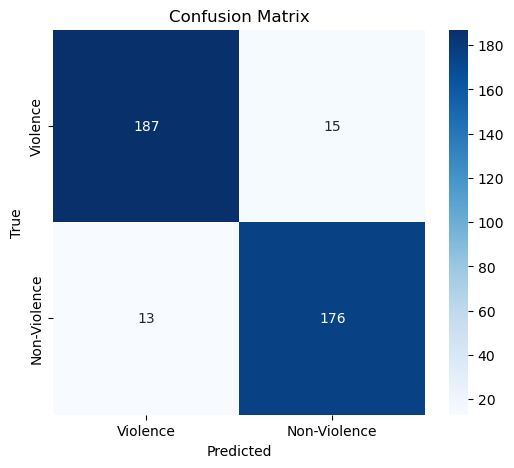

In [4]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Violence", "Non-Violence"],
            yticklabels=["Violence", "Non-Violence"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [1]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Violence", "Non-Violence"],
            yticklabels=["Violence", "Non-Violence"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'confusion_matrix' is not defined

In [2]:
import os
print(os.getcwd())

C:\Users\gabri


In [5]:
print("\nClassification Report:\n")
print(classification_report(
    y_true, y_pred,
    target_names=["Violence", "Non-Violence"]
))



Classification Report:

              precision    recall  f1-score   support

    Violence       0.94      0.93      0.93       202
Non-Violence       0.92      0.93      0.93       189

    accuracy                           0.93       391
   macro avg       0.93      0.93      0.93       391
weighted avg       0.93      0.93      0.93       391



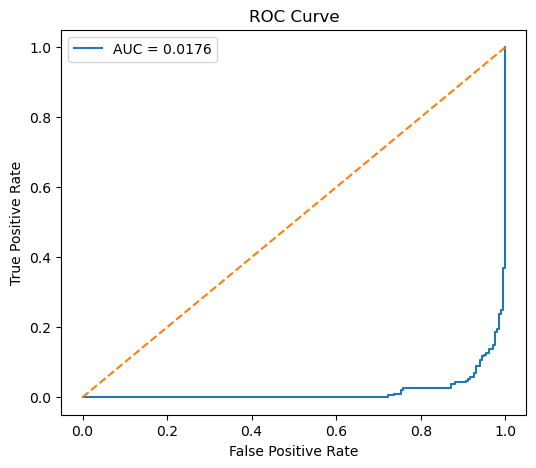

AUC: 0.01762795327151763


In [6]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)


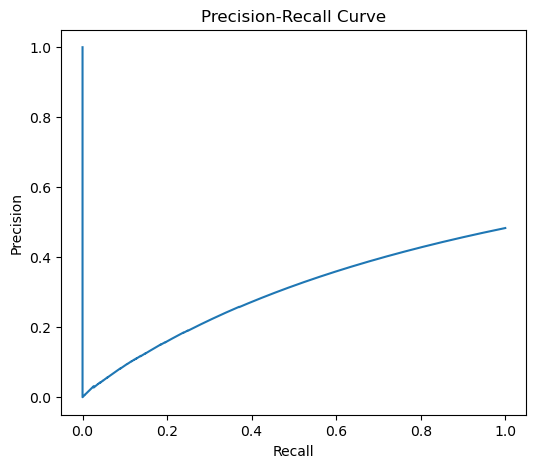

In [7]:
precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [8]:
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))


Precision: 0.9214659685863874
Recall: 0.9312169312169312
F1 Score: 0.9263157894736842


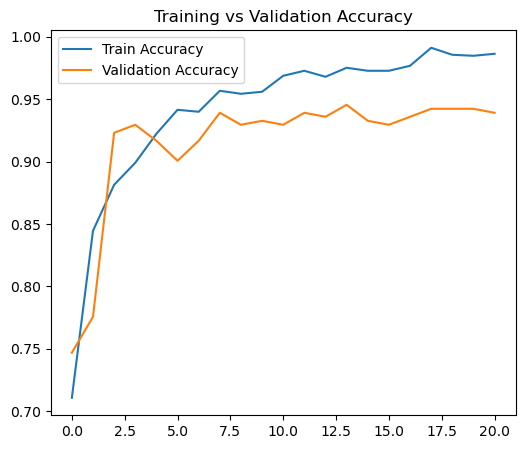

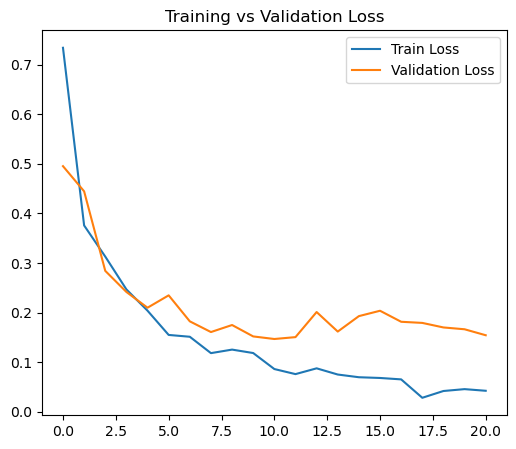

In [9]:
# Accuracy
plt.figure(figsize=(6,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(6,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [10]:
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)


Sensitivity (Recall): 0.9312169312169312
Specificity: 0.9257425742574258


In [11]:
model.save("violence_detection_cnn_bilstm.h5")
print("Model saved successfully!")

Model saved successfully!


In [11]:
# import os
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# OUTPUT_DIR = "test_visualizations"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# label_map = {0: "Violence", 1: "Non-Violence"}

# for i, video_name in enumerate(test_names):

#     # Extract frames again
#     video_path = os.path.join(DATA_DIR, video_name)
#     cap = cv2.VideoCapture(video_path)

#     frames = []
#     while len(frames) < FRAMES_PER_VIDEO:
#         ret, frame = cap.read()
#         if not ret:
#             break
#         frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         frame_resized = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
#         frames.append(frame_resized)

#     cap.release()

#     if len(frames) < FRAMES_PER_VIDEO:
#         continue

#     frames_array = np.array(frames, dtype=np.float32)
#     frames_array = preprocess_input(frames_array)

#     # Extract features
#     features = cnn.predict(frames_array, verbose=0)
#     sequence = np.expand_dims(features, axis=0)

#     prediction = model.predict(sequence, verbose=0)[0]
#     y_true = np.argmax(test_labels[i])
#     y_pred = np.argmax(prediction)

#     prob = float(max(prediction))

#     # Take middle frame for visualization
#     vis_frame = frames[len(frames)//2]

#     # Overlay info
#     text1 = f"True: {label_map[y_true]}"
#     text2 = f"Pred: {label_map[y_pred]}"
#     text3 = f"Prob: {prob:.2f}"
#     text4 = "Correct" if y_true == y_pred else "Incorrect"

#     color = (0,255,0) if y_true == y_pred else (255,0,0)

#     vis_frame_bgr = cv2.cvtColor(vis_frame, cv2.COLOR_RGB2BGR)

#     cv2.putText(vis_frame_bgr, text1, (10,30),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
#     cv2.putText(vis_frame_bgr, text2, (10,60),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
#     cv2.putText(vis_frame_bgr, text3, (10,90),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
#     cv2.putText(vis_frame_bgr, text4, (10,120),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

#     save_path = os.path.join(OUTPUT_DIR, f"sample_{i}.png")
#     cv2.imwrite(save_path, vis_frame_bgr)

# print("Test visualizations saved.")

In [12]:
# -----------------------------
# DIAGNOSTIC ANALYSIS
# -----------------------------

print("\nClass distribution:")
print("Train class distribution:", np.sum(y_train, axis=0))
print("Test class distribution :", np.sum(y_test, axis=0))

print("\nPrediction bias check:")
preds = model.predict(X_test)
print("Mean predicted probabilities:", np.mean(preds, axis=0))



Class distribution:
Train class distribution: [798 762]
Test class distribution : [202 189]

Prediction bias check:
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Mean predicted probabilities: [0.50874984 0.49125016]
